<a href="https://colab.research.google.com/github/daniel-delacruz-hdz/Robot-Planar-2GDL-simulacion/blob/main/PIA_Robot%20Planar%202GDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

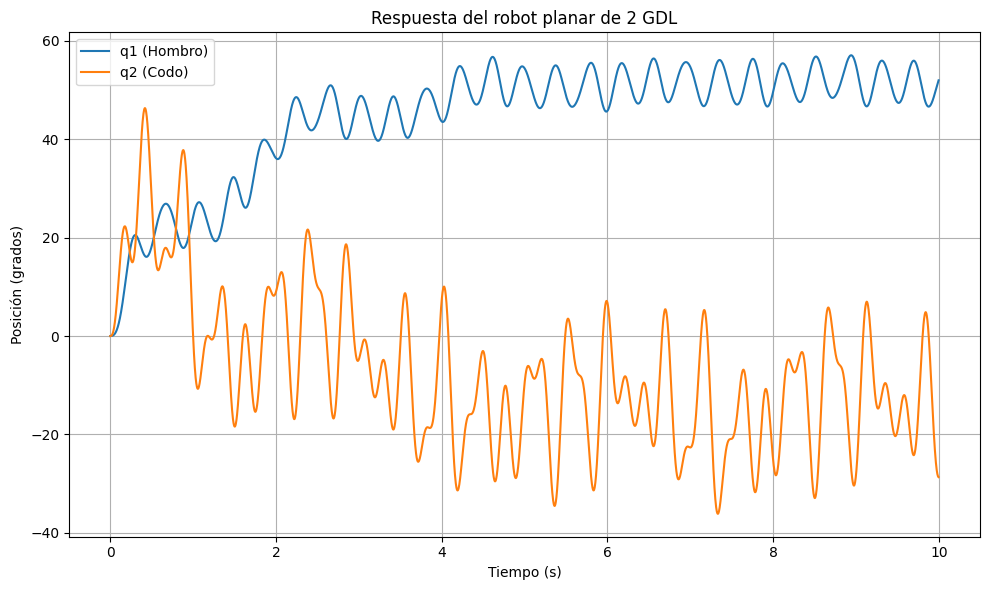

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# 1. Definición de la Dinámica (Equivalente al modelo del robot)
# -----------------------------------------------------------------
def f(t, x):
    # Vector de estado: q = [q1, q2], qp = [qp1, qp2]
    q = x[0:2]
    qp = x[2:4]

    # Matrices dinámicas (Valores numéricos de la p. 316)
    M = np.array([
        [3.117 + 0.2 * np.cos(q[1]), 0.108 + 0.1 * np.cos(q[1])],
        [0.108 + 0.1 * np.cos(q[1]), 0.108]
    ])

    C = np.array([
        [-0.2 * np.sin(q[1]) * qp[1], -0.1 * np.sin(q[1]) * qp[1]],
        [0.1 * np.sin(q[1]) * qp[0], 0.0]
    ])

    g = np.array([
        39.3 * np.sin(q[0]) + 1.95 * np.sin(q[0] + q[1]),
        1.95 * np.sin(q[0] + q[1])
    ])

    # Fricción viscosa y Coulomb (p. 316)
    fr = np.array([
        1.86 * qp[0] + 1.93 * np.tanh(1000 * qp[0]),
        0.16 * qp[1] + 0.3 * np.tanh(1000 * qp[1])
    ])

    # Torque aplicado (Ecuación 5.44, p. 317)
    tau = np.array([
        (1 - np.exp(-0.8 * t)) * 32.0 + 56 * np.sin(16 * t + 0.1) + 12 * np.sin(20 * t + 0.15),
        (1 - np.exp(-1.8 * t)) * 1.2 + 8 * np.sin(26 * t + 0.08) + 2 * np.sin(12 * t + 0.34)
    ])

    # Cálculo de aceleración: qpp = inv(M) * (tau - C*qp - g - fr)
    qpp = np.linalg.inv(M) @ (tau - C @ qp - g - fr)

    # Devolver derivadas: [qp1, qp2, qpp1, qpp2]
    return [qp[0], qp[1], qpp[0], qpp[1]]

# -----------------------------------------------------------------
# 2. Script Principal de Simulación
# -----------------------------------------------------------------
# Parámetros de simulación (p. 317)
ti, tf, h = 0.0, 10.0, 0.0025
ts = np.arange(ti, tf, h)

# Condiciones iniciales
x0 = [0, 0, 0, 0] # [q1, q2, qp1, qp2]

# Resolución
sol = solve_ivp(f, [ti, tf], x0, t_eval=ts, method='RK45')

# Conversión a grados para graficar
q1_deg = np.rad2deg(sol.y[0])
q2_deg = np.rad2deg(sol.y[1])

# Creación de gráficas
plt.figure(figsize=(10, 6))
plt.plot(sol.t, q1_deg, label='q1 (Hombro)')
plt.plot(sol.t, q2_deg, label='q2 (Codo)')
plt.title('Respuesta del robot planar de 2 GDL')
plt.xlabel('Tiempo (s)')
plt.ylabel('Posición (grados)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()